In [1]:

from data.movie import Frames, Audio

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import quantities as pq
import neo
from elephant.gpfa import GPFA
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

import torch
from torchvision import models, transforms
from torchvision.models.feature_extraction import create_feature_extractor
from PIL import Image

## RAW Data

In [2]:
# plt.figure(figsize=(35, 3))
# plt.eventplot(spk, orientation='horizontal')
# plt.xlabel('Time (s)')
# plt.ylabel('Neuron index')
# plt.title('Raster of subject CS58')
# plt.show()

## Dim reduction

### Stimulus


In [3]:
# Movie
fr = Frames()
l2 = fr.measures.l2.rescale(1.0)

au = Audio()
tim = au.instruments.timbre
vol = au.instruments.volume


100%|██████████| 144/144 [00:00<00:00, 258.85it/s]


#### Frame embedding

In [4]:
# 1) Load pretrained AlexNet and grab the fc7 features
alexnet = models.alexnet(weights="AlexNet_Weights.DEFAULT").eval()
return_nodes = {'classifier.5': 'fc7'}
fe = create_feature_extractor(alexnet, return_nodes)

# 2) ImageNet‐style preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),             # shorter edge → 256 px
    transforms.CenterCrop(224),         # → 224×224
    transforms.ToTensor(),              # → [0,1] C×H×W
    transforms.Normalize(               # ImageNet mean/std
      mean=[0.485, 0.456, 0.406],
      std=[0.229, 0.224, 0.225]
    ),
])

def embed_frames(frames: np.ndarray) -> np.ndarray:
    """
    frames: np.ndarray of shape (T, H, W), grayscale [0–255]
    returns: np.ndarray of shape (T, 4096)
    """
    T = frames.shape[0]
    embeds = np.zeros((T, 4096), dtype=np.float32)
    for t in tqdm(range(T)):
        # 1) convert to PIL RGB
        img = Image.fromarray(frames[t].astype(np.uint8)).convert('RGB')
        # 2) preprocess & batch
        x = preprocess(img).unsqueeze(0)           # 1×3×224×224
        # 3) forward‐pass
        with torch.no_grad():
            out = fe(x)['fc7']                    # 1×4096
        embeds[t] = out.cpu().squeeze(0).numpy()   # → (4096,)
    return embeds

In [5]:
fr.rescale(1.0).shape  # rescale to seconds

(479, 480, 720)

In [6]:
frames = fr.rescale(1.0)
embeddings = embed_frames(frames)
embeddings.shape

  0%|          | 0/479 [00:00<?, ?it/s]

100%|██████████| 479/479 [00:05<00:00, 81.86it/s]


(479, 4096)

In [7]:
embeddings[0]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

#### All stims

In [8]:
# Movie
l2 = fr.measures.l2.rescale(1.0).reshape(-1, 1)
tim = au.instruments.timbre.rescale(1.0).reshape(-1, 1)
vol = au.instruments.volume.rescale(1.0).reshape(-1, 1)

# S = np.hstack([embeddings, l2, tim, vol])

# not putting embeddings in S this time
S = np.hstack([l2, tim, vol, frames.reshape(frames.shape[0], -1)])

#### PCA down

In [9]:
pca = PCA()
S_pca = pca.fit_transform(S)
cumvar = np.cumsum(pca.explained_variance_ratio_)
# cumvar

In [10]:
# 4) find the number of components needed for 95% 
thresh = 0.95
n95 = np.searchsorted(cumvar, thresh) + 1
print(f"{n95} components explain ≥{int(thresh*100)}% of variance")

217 components explain ≥95% of variance


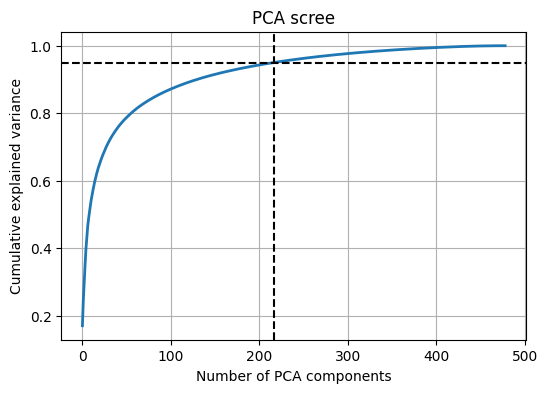

In [11]:
plt.figure(figsize=(6,4))
plt.plot(cumvar, lw=2)
plt.axhline(thresh, color='k', ls='--')
plt.axvline(n95,   color='k', ls='--')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA scree')
plt.grid(True)
plt.show()

### Neural

In [12]:
# Spikes
raw = pd.read_parquet('raw_spikes.parquet')

# sess, neurons, times
all_spk_times = []

for sess in tqdm(raw.sess.unique()):
    spike_data = raw[raw.sess==sess].enc_spikes.to_list()
    if len(spike_data) > 15:
        all_spk_times.append(spike_data[:15])

100%|██████████| 29/29 [00:00<00:00, 6197.95it/s]


In [13]:
len(all_spk_times)

25

#### Finding how many dims the spikes live in

In [14]:
T = 479 # total time in seconds

In [15]:
spiketrains = []
for neurons in all_spk_times:
    t_spk = []
    num_neurons = len(neurons)
    for n in range(num_neurons):
        st = neo.SpikeTrain(
            times=neurons[n] * pq.s,
            t_start=0*pq.s,
            t_stop=T*pq.s
        )
        t_spk.append(st)
    spiketrains.append(t_spk)

# # Folding time for cross-validation
# trials = []
# for start in [0, 160, 320]:
#     t0 = start   * pq.s
#     t1 = (start + 160) * pq.s
#     trials.append([st.time_slice(t0, t1) for st in spiketrains])


In [16]:
# x_dims = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# log_likelihoods = []
# for x_dim in x_dims:
#     gpfa_cv = GPFA(bin_size=1*pq.s, x_dim=x_dim)
#     cv_log_likelihoods = cross_val_score(gpfa_cv, spiketrains, cv=3, n_jobs=1, verbose=True)
#     log_likelihoods.append(np.mean(cv_log_likelihoods))

In [17]:
# import matplotlib
# matplotlib.use('Qt5Agg')

# from matplotlib import pyplot as plt

In [18]:
# f = plt.figure(figsize=(10, 3))
# plt.xlabel('Dimensionality of latent variables')
# plt.ylabel('Log-likelihood')
# plt.title('GPFA 3-fold cross-validation log-likelihoods')
# plt.plot(x_dims, log_likelihoods, '.-')
# plt.plot(x_dims[np.argmax(log_likelihoods)], np.max(log_likelihoods), 'x', markersize=10, color='r')
# # plt.tight_layout()
# plt.show()

#### Now that we know spikes are 4d, full reduction

In [19]:
gpfa_best = GPFA(bin_size=1*pq.s, x_dim=4)

In [20]:
y = gpfa_best.fit_transform(spiketrains)

Initializing parameters using factor analysis...

Fitting GPFA model...


In [23]:
# a, b, c, d = y["latent_variable_orth"][0]

# plt.figure(figsize=(5, 5))
# # colors from red to blue
# cmap = sns.color_palette("Blues", as_cmap=True)
# plt.scatter(a, b, c=np.arange(len(a)), cmap=cmap, s=20, edgecolor='none')
# plt.xlabel('Latent dimension 1')
# plt.ylabel('Latent dimension 2')
# plt.title('GPFA Latent Variables')
# plt.grid()
# plt.show()

In [ ]:
# from viziphant.gpfa import plot_dimensions_vs_time, plot_trajectories, plot_trajectories_spikeplay

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

In [46]:
plot_dimensions_vs_time(y, gpfa_best, dimensions=[0, 1, 2, 3])
plt.savefig('gpfa_dimensions_vs_time.png', dpi=300)

In [38]:
# plot_trajectories_spikeplay(spiketrains[0], y, gpfa_best)

# Decoding

In [65]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [ ]:
Y = y[0].T
Y.shape # (479, 4)
S_pca.shape #(479, 479)

tscv   = TimeSeriesSplit(n_splits=4)                # 4 contiguous folds
alphas = np.logspace(-3, 3, 7)                      # ridge penalty gri

ks    = np.arange(1, S_pca.shape[1]+1)
mean_r2 = np.zeros_like(ks, dtype=float)
mean_mse = np.zeros_like(ks, dtype=float)

for i, k in tqdm(enumerate(ks), total=len(ks), desc='Fitting models'):
    Xk = S_pca[:, :k]   # only first k PCA dims

    r2_folds = []
    mse_folds = []
    for train_idx, test_idx in tscv.split(Xk):
        X_tr, X_te = Xk[train_idx], Xk[test_idx]
        Y_tr, Y_te = Y[train_idx],  Y[test_idx]

        # multi-output ridge: fits one regressor per latent dim under the hood
        model = RidgeCV(alphas=alphas, cv=3)
        model.fit(X_tr, Y_tr)

        Y_pred = model.predict(X_te)
        # average R² across the M latent dims
        r2_folds.append(r2_score(Y_te, Y_pred, multioutput='uniform_average'))
        mse_folds.append(mean_squared_error(Y_te, Y_pred, multioutput='uniform_average'))

    mean_r2[i] = np.mean(r2_folds)
    mean_mse[i] = np.mean(mse_folds)

plt.figure(figsize=(6,4))
plt.plot(ks, mean_mse, lw=2)
plt.xlabel('Number of stimulus PCA dims (k)')
plt.ylabel('CV MSE predicting GPFA latents')
plt.title('How many movie dims to reconstruct neural latents?')
plt.grid(True)
plt.savefig('pca_vs_gpfa_mse.png', dpi=300)


Fitting models: 100%|██████████| 479/479 [00:40<00:00, 11.88it/s]


In [ ]:
# ── 3) PLOT & READ OFF “BRAIN” COMPRESSION ─────────────────────────────────
plt.figure(figsize=(6,4))
plt.plot(ks, mean_mse, lw=2)
plt.xlabel('Number of stimulus PCA dims (k)')
plt.ylabel('CV MSE predicting GPFA latents')
plt.title('How many movie dims to reconstruct neural latents?')
plt.grid(True)
plt.savefig('pca_vs_gpfa_mse.png', dpi=300)

# plt.ylim(-1, 1.05)
# best = mean_mse.max()
# plt.axhline(best * 0.95, color='k', ls='--',
#             label=f'95% of peak ($R^2$={best:.2f})')
# plt.legend(loc='lower right')
# plt.show()

# k95 = ks[np.argmax(mean_mse >= best * 0.95)]
# print(f"→ You only need k = {k95} PCs to reach 95% of peak R²")

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


In [ ]:
# hyperparameter grid
alphas = np.logspace(-3, 3, 7)

ks = np.arange(1, S_pca.shape[1] + 1)
train_r2 = np.zeros_like(ks, dtype=float)
train_mse = np.zeros_like(ks, dtype=float)

for i, k in tqdm(list(enumerate(ks)), total=len(ks), desc='Fitting models'):
    Xk = S_pca[:, :k]          # first k PCA dims

    # fit once on all time points
    model = RidgeCV(alphas=alphas, cv=3)
    model.fit(Xk, Y)

    Y_pred = model.predict(Xk)
    train_r2[i]  = r2_score(Y, Y_pred, multioutput='uniform_average')
    train_mse[i] = mean_squared_error(Y, Y_pred, multioutput='uniform_average')

# plot training MSE vs k
plt.figure(figsize=(6,4))
plt.plot(ks, train_mse, lw=2)
plt.xlabel('Number of stimulus PCA dims (k)')
plt.ylabel('Training MSE predicting GPFA latents')
plt.title('How many movie dims to reconstruct neural latents?')
plt.grid(True)
plt.savefig('pca_vs_gpfa_mse_2.png', dpi=300)
plt.show()




Fitting models: 100%|██████████| 479/479 [00:18<00:00, 26.19it/s]
/tmp/ipykernel_426976/296244136.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [70]:
# plot training R² vs k
plt.figure(figsize=(6,4))
plt.plot(ks, train_r2, lw=2)
plt.xlabel('Number of stimulus PCA dims (k)')
plt.ylabel('Training R² predicting GPFA latents')
plt.title('How many movie dims to reconstruct neural latents?')
plt.grid(True)
plt.savefig('pca_vs_gpfa_r2_2.png', dpi=300)
plt.show()


/tmp/ipykernel_426976/2124698393.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
